<a href="https://colab.research.google.com/github/VanDuy18/Bearing-Fault-Diagnosis/blob/main/MAFAULDA_PyTorch_4block_CNN_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Huấn luyện 2D-CNN 4 khối cho dữ liệu STFT MAFAULDA — PyTorch tối ưu

Số filter:

\[
32 \rightarrow 64 \rightarrow 128 \rightarrow 256
\]

Điểm thay đổi chính là dùng các hàm tối ưu sẵn của PyTorch:

- `nn.Conv2d`
- `nn.BatchNorm2d`
- `nn.ReLU`
- `nn.MaxPool2d`
- `nn.AdaptiveAvgPool2d`
- `nn.Linear`
- `nn.CrossEntropyLoss`
- `torch.optim.Adam`
- `Dataset` và `DataLoader`
- `torch.softmax`

Mỗi cửa sổ STFT vẫn được huấn luyện bằng **một model riêng từ đầu**. Cả 4 cửa sổ dùng cùng kiến trúc, cùng batch size, learning rate và cách chia dữ liệu để so sánh công bằng.


In [ ]:

# Ô 1 - Mount Google Drive

from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:

# Ô 2 - Import

from pathlib import Path

import copy
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader,
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from tqdm.auto import tqdm


In [ ]:

# Ô 3 - Cấu hình chung

DATA_ROOT = Path(
    "/content/drive/MyDrive/stft_dataset_split_balanced"
)

# Lưu sang thư mục mới để không ghi đè kết quả của code thủ công.
RESULT_ROOT = Path(
    "/content/drive/MyDrive/pytorch_4block_cnn_results"
)

CLASS_TO_LABEL = {
    "normal": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball_fault": 3,
}

CLASS_NAMES = [
    "Normal",
    "Inner race",
    "Outer race",
    "Ball fault",
]

STFT_VARIANTS = [
    {
        "name": "Nw_128_H_62_65x65",
        "nw": 128,
        "h": 62,
        "image_size": 65,
    },
    {
        "name": "Nw_256_H_30_129x129",
        "nw": 256,
        "h": 30,
        "image_size": 129,
    },
    {
        "name": "Nw_512_H_14_257x257",
        "nw": 512,
        "h": 14,
        "image_size": 257,
    },
    {
        "name": "Nw_1024_H_6_513x513",
        "nw": 1024,
        "h": 6,
        "image_size": 513,
    },
]

# Dùng cùng batch size cho cả 4 cửa sổ.
BATCH_SIZE = 2

EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0
EARLY_STOPPING_PATIENCE = 8

RANDOM_SEED = 42

# Google Colab có thể dùng 2 worker để đọc dữ liệu song song.
# Nếu DataLoader báo lỗi, đổi thành 0.
NUM_WORKERS = 2

# Chạy thử:
# MAX_TRAIN_SAMPLES = 200
# MAX_VAL_SAMPLES = 80
# MAX_TEST_SAMPLES = 80
#
# Huấn luyện chính thức:
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

PIN_MEMORY = (
    DEVICE.type == "cuda"
)

print("DATA_ROOT   :", DATA_ROOT)
print("RESULT_ROOT :", RESULT_ROOT)
print("DEVICE      :", DEVICE)
print("BATCH_SIZE  :", BATCH_SIZE)
print("NUM_WORKERS :", NUM_WORKERS)
print("PyTorch     :", torch.__version__)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


DATA_ROOT   : /content/drive/MyDrive/stft_dataset_split_balanced
RESULT_ROOT : /content/drive/MyDrive/pytorch_4block_cnn_results
DEVICE      : cuda
BATCH_SIZE  : 2
NUM_WORKERS : 2
PyTorch     : 2.11.0+cu128
GPU: Tesla T4



## Cấu trúc dữ liệu

Notebook giả sử dữ liệu có dạng:

```text
stft_dataset_split_balanced/
├── train/
├── validation/
└── test/
    ├── normal/
    ├── inner_race/
    ├── outer_race/
    └── ball_fault/
```

Trong mỗi tốc độ có các thư mục:

```text
Nw_128_H_62_65x65
Nw_256_H_30_129x129
Nw_512_H_14_257x257
Nw_1024_H_6_513x513
```


In [ ]:

# Ô 4 - Random seed

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Giữ tính tái lập tương đối ổn định.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


In [ ]:

# Ô 5 - Quét dữ liệu NPY

def collect_records(
    split_name,
    variant_name,
    max_samples=None
):
    records = []

    split_root = (
        DATA_ROOT
        / split_name
    )

    if not split_root.exists():
        raise FileNotFoundError(
            f"Không tìm thấy: {split_root}"
        )

    for class_key, label in CLASS_TO_LABEL.items():

        class_root = (
            split_root
            / class_key
        )

        if not class_root.exists():
            raise FileNotFoundError(
                f"Không tìm thấy: {class_root}"
            )

        class_files = []

        for npy_path in class_root.rglob(
            "segment_*.npy"
        ):
            if (
                npy_path.parent.name
                == variant_name
            ):
                class_files.append(
                    npy_path
                )

        class_files = sorted(
            class_files
        )

        for npy_path in class_files:
            records.append(
                {
                    "path": npy_path,
                    "label": label,
                    "class_key": class_key,
                }
            )

    records = sorted(
        records,
        key=lambda r: (
            r["label"],
            str(r["path"])
        )
    )

    if max_samples is not None:
        records = records[
            :max_samples
        ]

    return records


def class_counts(records):

    counts = {
        name: 0
        for name in CLASS_NAMES
    }

    for record in records:

        counts[
            CLASS_NAMES[
                record["label"]
            ]
        ] += 1

    return counts


# Kiểm tra số mẫu ở cả 4 cửa sổ.
for variant in STFT_VARIANTS:

    print(
        "\n",
        variant["name"]
    )

    for split_name in [
        "train",
        "validation",
        "test",
    ]:

        records = collect_records(
            split_name,
            variant["name"]
        )

        print(
            f"{split_name:10s}: "
            f"{len(records):6d} | "
            f"{class_counts(records)}"
        )



 Nw_128_H_62_65x65
train     :   8296 | {'Normal': 2074, 'Inner race': 2074, 'Outer race': 2074, 'Ball fault': 2074}
validation:   1708 | {'Normal': 427, 'Inner race': 427, 'Outer race': 427, 'Ball fault': 427}
test      :   1952 | {'Normal': 488, 'Inner race': 488, 'Outer race': 488, 'Ball fault': 488}

 Nw_256_H_30_129x129
train     :   8296 | {'Normal': 2074, 'Inner race': 2074, 'Outer race': 2074, 'Ball fault': 2074}
validation:   1708 | {'Normal': 427, 'Inner race': 427, 'Outer race': 427, 'Ball fault': 427}
test      :   1952 | {'Normal': 488, 'Inner race': 488, 'Outer race': 488, 'Ball fault': 488}

 Nw_512_H_14_257x257
train     :   8296 | {'Normal': 2074, 'Inner race': 2074, 'Outer race': 2074, 'Ball fault': 2074}
validation:   1708 | {'Normal': 427, 'Inner race': 427, 'Outer race': 427, 'Ball fault': 427}
test      :   1952 | {'Normal': 488, 'Inner race': 488, 'Outer race': 488, 'Ball fault': 488}

 Nw_1024_H_6_513x513
train     :   8296 | {'Normal': 2074, 'Inner race': 2074

In [ ]:

# Ô 6 - Dataset + DataLoader có sẵn

class STFTDataset(Dataset):

    def __init__(
        self,
        records,
        image_size
    ):
        self.records = records
        self.image_size = image_size

    def __len__(self):
        return len(
            self.records
        )

    def __getitem__(
        self,
        index
    ):
        record = (
            self.records[index]
        )

        x = np.load(
            record["path"],
            allow_pickle=False
        ).astype(
            np.float32
        )

        expected_shape = (
            self.image_size,
            self.image_size
        )

        if x.shape != expected_shape:
            raise ValueError(
                f"Sai shape {x.shape}; "
                f"cần {expected_shape}\n"
                f"{record['path']}"
            )

        if not np.all(
            np.isfinite(x)
        ):
            raise ValueError(
                f"NaN/Inf tại "
                f"{record['path']}"
            )

        # [H,W] -> [1,H,W]
        x_tensor = (
            torch.from_numpy(x)
            .unsqueeze(0)
        )

        y_tensor = torch.tensor(
            record["label"],
            dtype=torch.long
        )

        return (
            x_tensor,
            y_tensor
        )


def make_loader(
    records,
    image_size,
    shuffle,
    seed
):

    dataset = STFTDataset(
        records=records,
        image_size=image_size
    )

    generator = torch.Generator()

    generator.manual_seed(
        seed
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
        generator=generator,
        persistent_workers=(
            NUM_WORKERS > 0
        ),
    )

    return loader


In [ ]:

# Ô 7 - Kiến trúc 2D-CNN 4 khối dùng hàm có sẵn

class Bearing2DCNN(nn.Module):

    def __init__(
        self,
        num_classes=4
    ):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1: 1 -> 32
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),

            nn.BatchNorm2d(
                32
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # Block 2: 32 -> 64
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),

            nn.BatchNorm2d(
                64
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # Block 3: 64 -> 128
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),

            nn.BatchNorm2d(
                128
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # Block 4: 128 -> 256
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),

            nn.BatchNorm2d(
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),
        )

        # Global Average Pooling.
        self.gap = nn.AdaptiveAvgPool2d(
            output_size=(1, 1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                128,
                num_classes
            ),
        )

    def forward(
        self,
        x
    ):

        x = self.features(
            x
        )

        x = self.gap(
            x
        )

        logits = self.classifier(
            x
        )

        return logits


In [ ]:

# Ô 8 - Kiểm tra kiến trúc với 4 kích thước ảnh

model_test = Bearing2DCNN(
    num_classes=len(
        CLASS_NAMES
    )
).to(
    DEVICE
)

number_of_parameters = sum(
    parameter.numel()
    for parameter
    in model_test.parameters()
    if parameter.requires_grad
)

print(
    "Số tham số có thể học:",
    f"{number_of_parameters:,}"
)

for size in [
    65,
    129,
    257,
    513,
]:

    x = torch.randn(
        1,
        1,
        size,
        size,
        device=DEVICE
    )

    with torch.no_grad():

        logits = model_test(
            x
        )

    print(
        f"Input {size}x{size}"
        f" -> Output "
        f"{tuple(logits.shape)}"
    )

del model_test

if torch.cuda.is_available():
    torch.cuda.empty_cache()


Số tham số có thể học: 421,732
Input 65x65 -> Output (1, 4)
Input 129x129 -> Output (1, 4)
Input 257x257 -> Output (1, 4)
Input 513x513 -> Output (1, 4)


In [ ]:

# Ô 9 - Hàm đánh giá Validation/Test

def evaluate_loader(
    model,
    loader,
    criterion,
    description="Validation",
    show_progress=False,
    measure_inference=False
):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []

    inference_time = 0.0

    iterator = loader

    if show_progress:

        iterator = tqdm(
            loader,
            desc=description,
            leave=False
        )

    with torch.no_grad():

        for x, y in iterator:

            x = x.to(
                DEVICE,
                non_blocking=True
            )

            y = y.to(
                DEVICE,
                non_blocking=True
            )

            if (
                measure_inference
                and DEVICE.type == "cuda"
            ):
                torch.cuda.synchronize()

            start_forward = (
                time.perf_counter()
                if measure_inference
                else None
            )

            logits = model(
                x
            )

            if (
                measure_inference
                and DEVICE.type == "cuda"
            ):
                torch.cuda.synchronize()

            if measure_inference:

                inference_time += (
                    time.perf_counter()
                    - start_forward
                )

            loss = criterion(
                logits,
                y
            )

            predictions = (
                logits.argmax(
                    dim=1
                )
            )

            B = y.size(0)

            total_loss += (
                loss.item()
                * B
            )

            total_samples += B

            y_true.extend(
                y.cpu()
                .numpy()
                .tolist()
            )

            y_pred.extend(
                predictions.cpu()
                .numpy()
                .tolist()
            )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=list(
                range(
                    len(CLASS_NAMES)
                )
            ),
            average="macro",
            zero_division=0,
        )
    )

    precision_class, recall_class, f1_class, support_class = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=list(
                range(
                    len(CLASS_NAMES)
                )
            ),
            average=None,
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(
            range(
                len(CLASS_NAMES)
            )
        )
    )

    per_class_df = pd.DataFrame(
        {
            "class":
                CLASS_NAMES,

            "precision":
                precision_class,

            "recall":
                recall_class,

            "f1":
                f1_class,

            "support":
                support_class,
        }
    )

    result = {
        "loss":
            total_loss
            / total_samples,

        "accuracy":
            float(
                accuracy
            ),

        "precision_macro":
            float(
                precision_macro
            ),

        "recall_macro":
            float(
                recall_macro
            ),

        "f1_macro":
            float(
                f1_macro
            ),

        "confusion_matrix":
            cm,

        "per_class":
            per_class_df,
    }

    if measure_inference:

        result[
            "inference_time_sec"
        ] = inference_time

        result[
            "inference_ms_per_sample"
        ] = (
            1000.0
            * inference_time
            / total_samples
        )

    return result


In [ ]:

# Ô 10 - Train một epoch

def train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    epoch
):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    progress_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch:02d}/{EPOCHS} "
            f"- Train"
        ),
        leave=False
    )

    for x, y in progress_bar:

        x = x.to(
            DEVICE,
            non_blocking=True
        )

        y = y.to(
            DEVICE,
            non_blocking=True
        )

        # 1. Xóa gradient batch trước.
        optimizer.zero_grad(
            set_to_none=True
        )

        # 2. Forward.
        logits = model(
            x
        )

        # 3. Cross Entropy Loss.
        loss = criterion(
            logits,
            y
        )

        # 4. Backpropagation.
        loss.backward()

        # 5. Adam cập nhật trọng số.
        optimizer.step()

        predictions = (
            logits.argmax(
                dim=1
            )
        )

        B = y.size(0)

        total_loss += (
            loss.item()
            * B
        )

        total_correct += (
            predictions
            == y
        ).sum().item()

        total_samples += B

        current_loss = (
            total_loss
            / total_samples
        )

        current_accuracy = (
            total_correct
            / total_samples
        )

        progress_bar.set_postfix(
            loss=(
                f"{current_loss:.4f}"
            ),
            acc=(
                f"{current_accuracy*100:.2f}%"
            )
        )

    return {
        "loss":
            total_loss
            / total_samples,

        "accuracy":
            total_correct
            / total_samples,
    }


In [ ]:

# Ô 11 - Huấn luyện một cửa sổ STFT

def train_one_variant(
    variant,
    train_records,
    val_records
):

    image_size = (
        variant["image_size"]
    )

    # Mỗi variant tạo model mới từ đầu.
    set_seed(
        RANDOM_SEED
    )

    train_loader = make_loader(
        records=train_records,
        image_size=image_size,
        shuffle=True,
        seed=RANDOM_SEED,
    )

    val_loader = make_loader(
        records=val_records,
        image_size=image_size,
        shuffle=False,
        seed=RANDOM_SEED,
    )

    model = Bearing2DCNN(
        num_classes=len(
            CLASS_NAMES
        )
    ).to(
        DEVICE
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_val_loss = float(
        "inf"
    )

    best_epoch = 0
    best_state = None

    patience_counter = 0

    history = []

    start_training = (
        time.perf_counter()
    )

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        epoch_start = (
            time.perf_counter()
        )

        train_result = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            epoch=epoch,
        )

        val_result = evaluate_loader(
            model=model,
            loader=val_loader,
            criterion=criterion,
            description=(
                f"Epoch "
                f"{epoch:02d}/{EPOCHS} "
                f"- Validation"
            ),
            show_progress=True,
            measure_inference=False,
        )

        epoch_time = (
            time.perf_counter()
            - epoch_start
        )

        row = {
            "epoch":
                epoch,

            "train_loss":
                train_result[
                    "loss"
                ],

            "train_accuracy":
                train_result[
                    "accuracy"
                ],

            "val_loss":
                val_result[
                    "loss"
                ],

            "val_accuracy":
                val_result[
                    "accuracy"
                ],

            "val_f1_macro":
                val_result[
                    "f1_macro"
                ],

            "epoch_time_sec":
                epoch_time,
        }

        history.append(
            row
        )

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss="
            f"{row['train_loss']:.5f} | "
            f"Train Acc="
            f"{row['train_accuracy']*100:6.2f}% | "
            f"Val Loss="
            f"{row['val_loss']:.5f} | "
            f"Val Acc="
            f"{row['val_accuracy']*100:6.2f}% | "
            f"Val F1="
            f"{row['val_f1_macro']*100:6.2f}% | "
            f"Time="
            f"{epoch_time:.1f}s"
        )

        # Lưu model có Validation Loss nhỏ nhất.
        if (
            row["val_loss"]
            < best_val_loss
        ):

            best_val_loss = (
                row["val_loss"]
            )

            best_epoch = (
                epoch
            )

            best_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

            patience_counter = 0

        else:

            patience_counter += 1

        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                f"Early stopping tại "
                f"epoch {epoch}."
            )

            break

    training_time = (
        time.perf_counter()
        - start_training
    )

    if best_state is None:
        raise RuntimeError(
            "Không có best_state."
        )

    model.load_state_dict(
        best_state
    )

    best_val_result = evaluate_loader(
        model=model,
        loader=val_loader,
        criterion=criterion,
        description="Best model - Validation",
        show_progress=True,
        measure_inference=False,
    )

    return {
        "model":
            model,

        "criterion":
            criterion,

        "history":
            history,

        "best_epoch":
            best_epoch,

        "training_time_sec":
            training_time,

        "val_result":
            best_val_result,
    }


In [ ]:

# Ô 12 - Lưu history, đồ thị và confusion matrix

def save_history_and_plots(
    history,
    output_dir
):

    history_df = pd.DataFrame(
        history
    )

    history_df.to_csv(
        output_dir
        / "training_history.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # Loss
    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label="Validation"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        "Train và Validation Loss"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        output_dir
        / "loss_curve.png",
        dpi=170
    )

    plt.show()

    # Accuracy
    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history_df["epoch"],
        history_df[
            "train_accuracy"
        ] * 100,
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df[
            "val_accuracy"
        ] * 100,
        label="Validation"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(
        "Train và Validation Accuracy"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        output_dir
        / "accuracy_curve.png",
        dpi=170
    )

    plt.show()


def save_confusion_matrix_plot(
    cm,
    output_path,
    title
):

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )

    figure, axis = plt.subplots(
        figsize=(7, 6)
    )

    display_cm.plot(
        ax=axis,
        values_format="d",
        xticks_rotation=30,
        colorbar=True,
    )

    axis.set_title(
        title
    )

    figure.tight_layout()

    figure.savefig(
        output_path,
        dpi=170
    )

    plt.show()

    plt.close(
        figure
    )



## Huấn luyện cả 4 cửa sổ

Ô dưới đây tạo lần lượt 4 model độc lập:

\[
N_w=128,\ 256,\ 512,\ 1024
\]

Mỗi model có file trọng số riêng:

```text
Nw_128.../best_model.pt
Nw_256.../best_model.pt
Nw_512.../best_model.pt
Nw_1024.../best_model.pt
```

Trong lúc chạy, progress bar sẽ hiển thị số batch đã xử lý, loss và accuracy hiện tại.



##########################################################################################
CỬA SỔ 1/4
Nw=128 | H=62 | STFT=65x65 | Batch=2
##########################################################################################
Train: 8296 {'Normal': 2074, 'Inner race': 2074, 'Outer race': 2074, 'Ball fault': 2074}
Validation: 1708 {'Normal': 427, 'Inner race': 427, 'Outer race': 427, 'Ball fault': 427}


Epoch 01/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

Epoch 01/30 - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

Epoch 01/30 | Train Loss=0.21261 | Train Acc= 92.03% | Val Loss=0.09464 | Val Acc= 96.96% | Val F1= 96.94% | Time=1927.1s


Epoch 02/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

...

Epoch 17/30 | Train Loss=0.00441 | Train Acc= 99.90% | Val Loss=0.01566 | Val Acc= 99.18% | Val F1= 99.18% | Time=42.6s


Epoch 18/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

Epoch 18/30 - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

Epoch 18/30 | Train Loss=0.00899 | Train Acc= 99.84% | Val Loss=0.00379 | Val Acc= 99.88% | Val F1= 99.88% | Time=40.8s
Early stopping tại epoch 18.


Best model - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

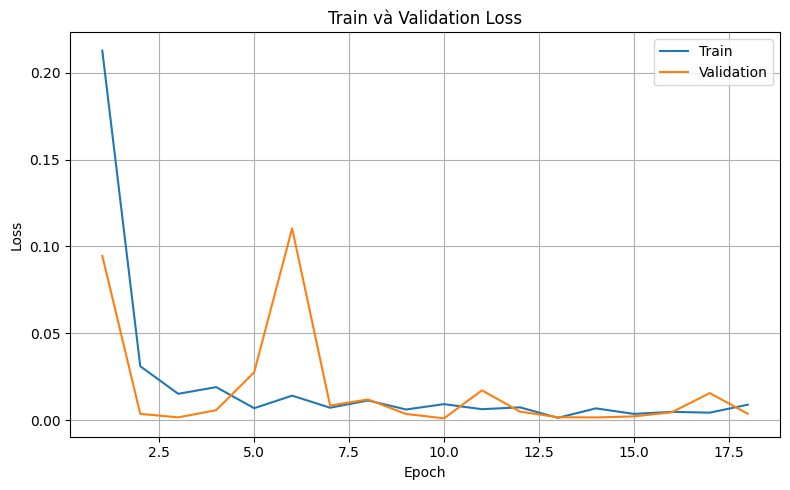

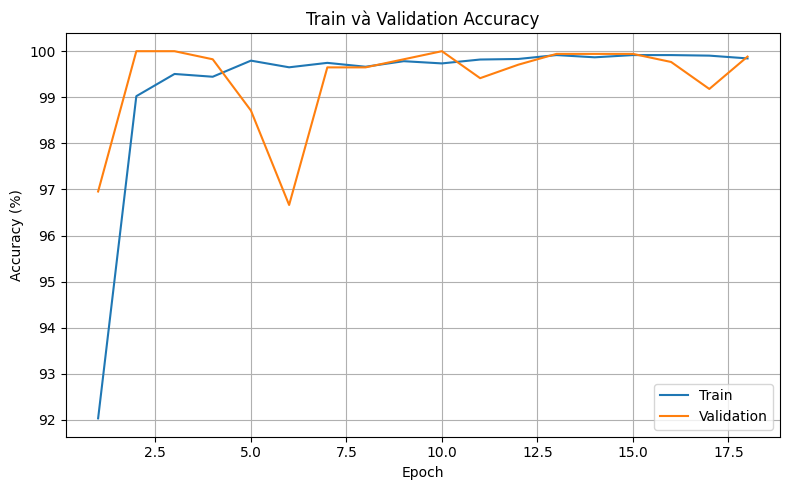

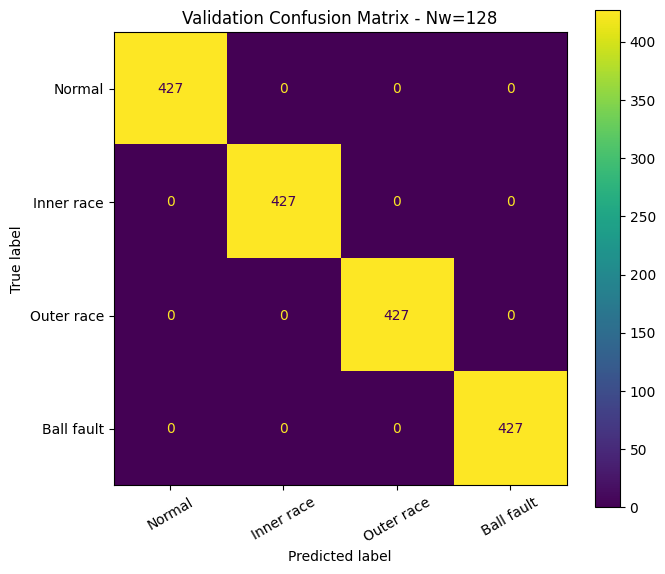

Best epoch = 10
Val Accuracy = 100.0000%
Val Macro F1 = 100.0000%
Training time = 2719.4s

##########################################################################################
CỬA SỔ 2/4
Nw=256 | H=30 | STFT=129x129 | Batch=2
##########################################################################################
Train: 8296 {'Normal': 2074, 'Inner race': 2074, 'Outer race': 2074, 'Ball fault': 2074}
Validation: 1708 {'Normal': 427, 'Inner race': 427, 'Outer race': 427, 'Ball fault': 427}


Epoch 01/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

Epoch 01/30 - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

Epoch 01/30 | Train Loss=0.23491 | Train Acc= 90.86% | Val Loss=0.01217 | Val Acc= 99.82% | Val F1= 99.82% | Time=1852.5s


Epoch 02/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

...

Epoch 29/30 | Train Loss=0.00223 | Train Acc= 99.93% | Val Loss=0.00007 | Val Acc=100.00% | Val F1=100.00% | Time=44.2s


Epoch 30/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

Epoch 30/30 - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss=0.00002 | Train Acc=100.00% | Val Loss=0.00000 | Val Acc=100.00% | Val F1=100.00% | Time=44.4s


Best model - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

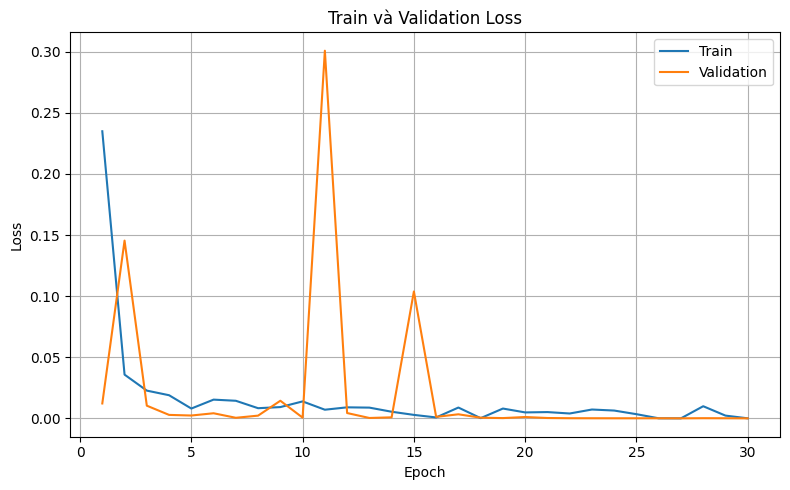

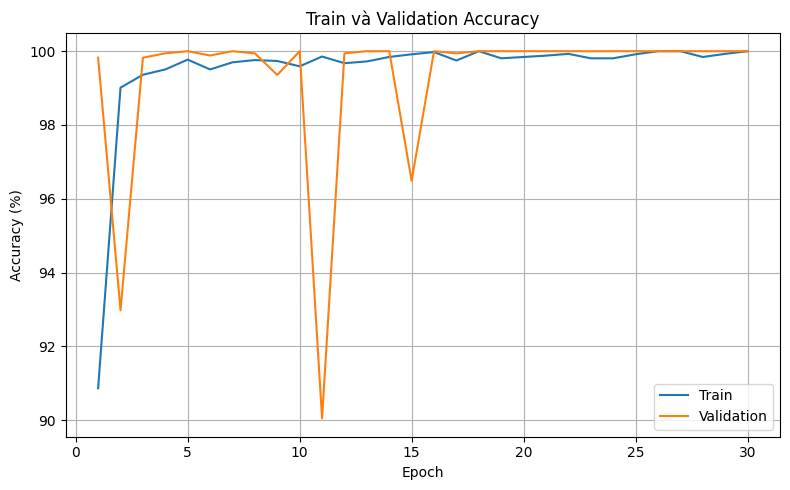

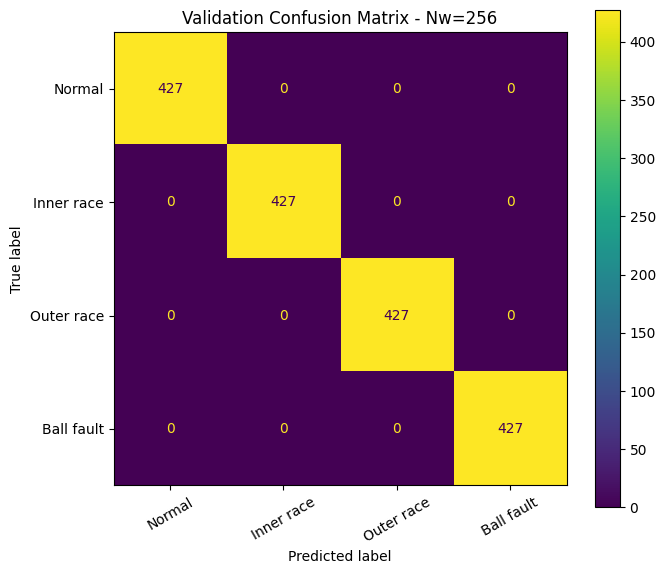

Best epoch = 27
Val Accuracy = 100.0000%
Val Macro F1 = 100.0000%
Training time = 3169.7s

##########################################################################################
CỬA SỔ 3/4
Nw=512 | H=14 | STFT=257x257 | Batch=2
##########################################################################################
Train: 8296 {'Normal': 2074, 'Inner race': 2074, 'Outer race': 2074, 'Ball fault': 2074}
Validation: 1708 {'Normal': 427, 'Inner race': 427, 'Outer race': 427, 'Ball fault': 427}


Epoch 01/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

Epoch 01/30 - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

Epoch 01/30 | Train Loss=0.46930 | Train Acc= 80.44% | Val Loss=0.03753 | Val Acc= 99.12% | Val F1= 99.12% | Time=2177.5s


Epoch 02/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

...

Epoch 15/30 | Train Loss=0.00726 | Train Acc= 99.82% | Val Loss=0.00105 | Val Acc=100.00% | Val F1=100.00% | Time=79.0s


Epoch 16/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

Epoch 16/30 - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

Epoch 16/30 | Train Loss=0.01128 | Train Acc= 99.66% | Val Loss=0.00197 | Val Acc= 99.88% | Val F1= 99.88% | Time=78.1s
Early stopping tại epoch 16.


Best model - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

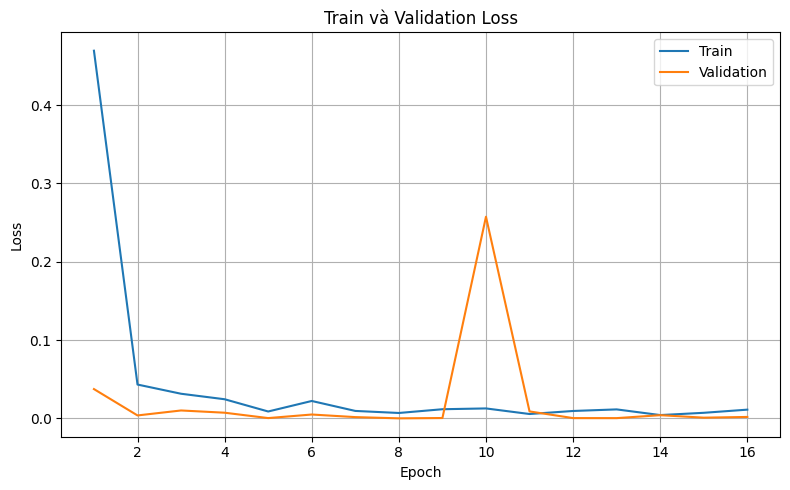

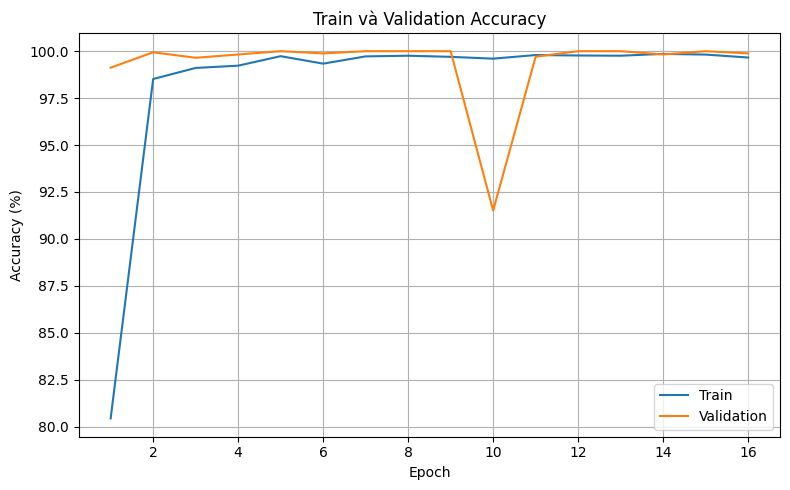

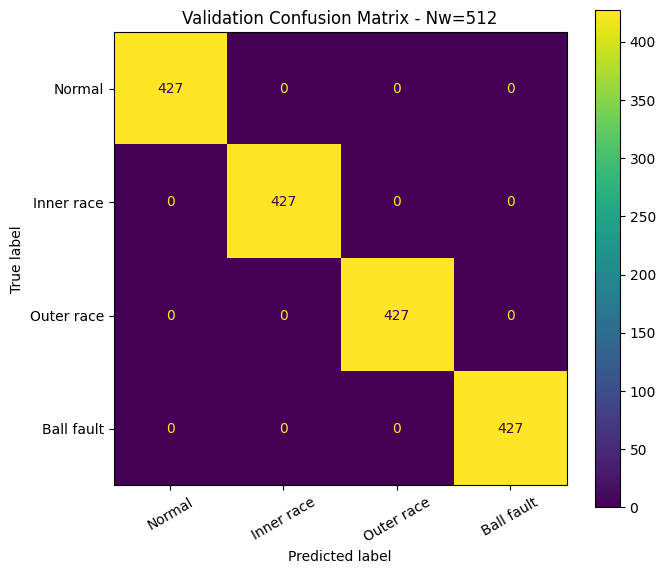

Best epoch = 8
Val Accuracy = 100.0000%
Val Macro F1 = 100.0000%
Training time = 3335.8s

##########################################################################################
CỬA SỔ 4/4
Nw=1024 | H=6 | STFT=513x513 | Batch=2
##########################################################################################
Train: 8296 {'Normal': 2074, 'Inner race': 2074, 'Outer race': 2074, 'Ball fault': 2074}
Validation: 1708 {'Normal': 427, 'Inner race': 427, 'Outer race': 427, 'Ball fault': 427}


Epoch 01/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78be24044a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78be24044a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 01/30 - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

Epoch 01/30 | Train Loss=0.78203 | Train Acc= 66.48% | Val Loss=0.13826 | Val Acc= 96.90% | Val F1= 96.89% | Time=2306.5s


...

Epoch 26/30 | Train Loss=0.00698 | Train Acc= 99.80% | Val Loss=0.02374 | Val Acc= 99.24% | Val F1= 99.24% | Time=139.3s


Epoch 27/30 - Train:   0%|          | 0/4148 [00:00<?, ?it/s]

Epoch 27/30 - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

Epoch 27/30 | Train Loss=0.00303 | Train Acc= 99.90% | Val Loss=0.00067 | Val Acc=100.00% | Val F1=100.00% | Time=145.9s
Early stopping tại epoch 27.


Best model - Validation:   0%|          | 0/854 [00:00<?, ?it/s]

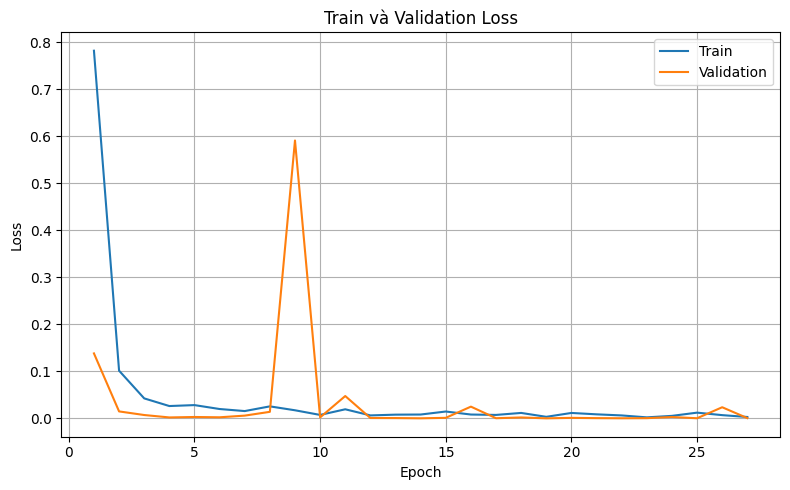

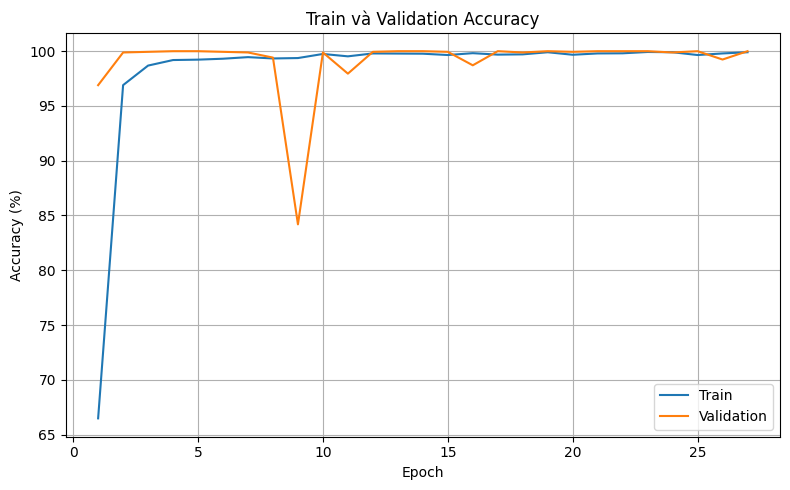

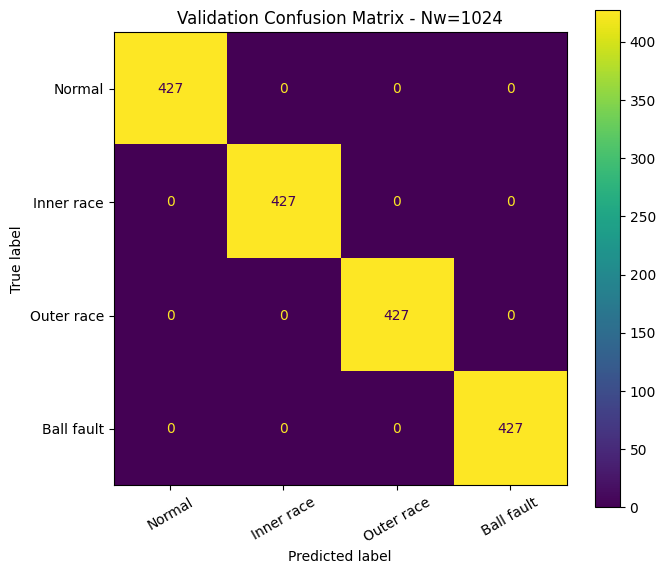

Best epoch = 19
Val Accuracy = 100.0000%
Val Macro F1 = 100.0000%
Training time = 6594.7s


In [ ]:

# Ô 13 - Huấn luyện cả 4 cửa sổ

RESULT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

validation_summary = []

for variant_index, variant in enumerate(
    STFT_VARIANTS,
    start=1
):

    variant_name = variant["name"]
    image_size = variant["image_size"]

    print("\n" + "#" * 90)

    print(
        f"CỬA SỔ "
        f"{variant_index}/"
        f"{len(STFT_VARIANTS)}"
    )

    print(
        f"Nw={variant['nw']} | "
        f"H={variant['h']} | "
        f"STFT={image_size}x{image_size} | "
        f"Batch={BATCH_SIZE}"
    )

    print("#" * 90)

    train_records = collect_records(
        "train",
        variant_name,
        MAX_TRAIN_SAMPLES
    )

    val_records = collect_records(
        "validation",
        variant_name,
        MAX_VAL_SAMPLES
    )

    print(
        "Train:",
        len(train_records),
        class_counts(train_records)
    )

    print(
        "Validation:",
        len(val_records),
        class_counts(val_records)
    )

    variant_dir = (
        RESULT_ROOT
        / variant_name
    )

    variant_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    result = train_one_variant(
        variant=variant,
        train_records=train_records,
        val_records=val_records
    )

    model = result["model"]

    # Lưu bộ trọng số tốt nhất.
    torch.save(
        model.state_dict(),
        variant_dir / "best_model.pt"
    )

    save_history_and_plots(
        result["history"],
        variant_dir
    )

    val_result = result["val_result"]

    # Lưu metrics từng lớp.
    val_result[
        "per_class"
    ].to_csv(
        variant_dir
        / "validation_per_class_metrics.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # Lưu confusion matrix dạng số.
    np.savetxt(
        variant_dir
        / "validation_confusion_matrix.csv",
        val_result["confusion_matrix"],
        delimiter=",",
        fmt="%d"
    )

    # Lưu confusion matrix dạng hình.
    save_confusion_matrix_plot(
        val_result["confusion_matrix"],
        variant_dir
        / "validation_confusion_matrix.png",
        title=(
            f"Validation Confusion Matrix "
            f"- Nw={variant['nw']}"
        ),
    )

    validation_summary.append(
        {
            "variant":
                variant_name,

            "nw":
                variant["nw"],

            "h":
                variant["h"],

            "image_size":
                image_size,

            "batch_size":
                BATCH_SIZE,

            "best_epoch":
                result["best_epoch"],

            "val_loss":
                val_result["loss"],

            "val_accuracy":
                val_result["accuracy"],

            "val_precision_macro":
                val_result["precision_macro"],

            "val_recall_macro":
                val_result["recall_macro"],

            "val_f1_macro":
                val_result["f1_macro"],

            "training_time_sec":
                result["training_time_sec"],
        }
    )

    print(
        f"Best epoch = "
        f"{result['best_epoch']}"
    )

    print(
        f"Val Accuracy = "
        f"{val_result['accuracy']*100:.4f}%"
    )

    print(
        f"Val Macro F1 = "
        f"{val_result['f1_macro']*100:.4f}%"
    )

    print(
        f"Training time = "
        f"{result['training_time_sec']:.1f}s"
    )

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [ ]:
import torch

# 1. Đường dẫn file đã chọn
model_path = '/content/drive/MyDrive/pytorch_4block_cnn_results/Nw_128_H_62_65x65/best_model.pt'

# 2. Khởi tạo kiến trúc mô hình (phải khớp với lúc train)
loaded_model = Bearing2DCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)

# 3. Nạp trọng số từ file
checkpoint = torch.load(model_path, map_location=DEVICE)
loaded_model.load_state_dict(checkpoint)

# 4. Chuyển sang chế độ đánh giá (Inference)
loaded_model.eval()

print(f"Đã nạp thành công trọng số từ: {model_path}")

In [ ]:

# Ô 14 - So sánh 4 cửa sổ bằng Validation

validation_df = pd.DataFrame(
    validation_summary
)

validation_df = (
    validation_df
    .sort_values(
        by=[
            "val_f1_macro",
            "val_accuracy",
            "val_loss",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

validation_df.insert(
    0,
    "rank",
    np.arange(
        1,
        len(validation_df) + 1
    )
)

validation_df.to_csv(
    RESULT_ROOT
    / "validation_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

display_df = (
    validation_df.copy()
)

for column in [
    "val_accuracy",
    "val_precision_macro",
    "val_recall_macro",
    "val_f1_macro",
]:
    display_df[column] *= 100

display(
    display_df[
        [
            "rank",
            "nw",
            "h",
            "image_size",
            "batch_size",
            "best_epoch",
            "val_loss",
            "val_accuracy",
            "val_precision_macro",
            "val_recall_macro",
            "val_f1_macro",
            "training_time_sec",
        ]
    ]
)

best_row = validation_df.iloc[0]

print(
    "\nCửa sổ được chọn bằng Validation:"
)

print(
    f"Nw={int(best_row['nw'])}, "
    f"H={int(best_row['h'])}, "
    f"STFT="
    f"{int(best_row['image_size'])}x"
    f"{int(best_row['image_size'])}"
)

print(
    f"Validation Macro F1 = "
    f"{best_row['val_f1_macro']*100:.4f}%"
)


,rank,nw,h,image_size,batch_size,best_epoch,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,training_time_sec
0,1,256,30,129,2,27,0.000002,100.0,100.0,100.0,100.0,3169.748649
1,2,1024,6,513,2,19,0.000152,100.0,100.0,100.0,100.0,6594.693988
2,3,512,14,257,2,8,0.000190,100.0,100.0,100.0,100.0,3335.830594
3,4,128,62,65,2,10,0.001135,100.0,100.0,100.0,100.0,2719.441114



Cửa sổ được chọn bằng Validation:
Nw=256, H=30, STFT=129x129
Validation Macro F1 = 100.0000%



## Test model tốt nhất

Tập Test **không dùng để chọn cửa sổ**.

Sau khi Validation xác định cửa sổ tốt nhất, code mới tải `best_model.pt` tương ứng và đánh giá trên Test.

Các chỉ tiêu Test:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Precision / Recall / F1 từng lớp
- Confusion Matrix
- Inference time trung bình trên một mẫu


Test samples: 1952
Class counts: {'Normal': 488, 'Inner race': 488, 'Outer race': 488, 'Ball fault': 488}


Test:   0%|          | 0/976 [00:00<?, ?it/s]


TEST RESULT
Accuracy         = 99.8463%
Macro Precision  = 99.8473%
Macro Recall     = 99.8463%
Macro F1         = 99.8463%
Inference/sample = 0.9818 ms

Metrics từng lớp:


,class,precision,recall,f1,support
0,Normal,1.00000,0.993852,0.996917,488
1,Inner race,0.99389,1.000000,0.996936,488
2,Outer race,1.00000,1.000000,1.000000,488
3,Ball fault,1.00000,1.000000,1.000000,488



Confusion matrix:
[[485   3   0   0]
 [  0 488   0   0]
 [  0   0 488   0]
 [  0   0   0 488]]


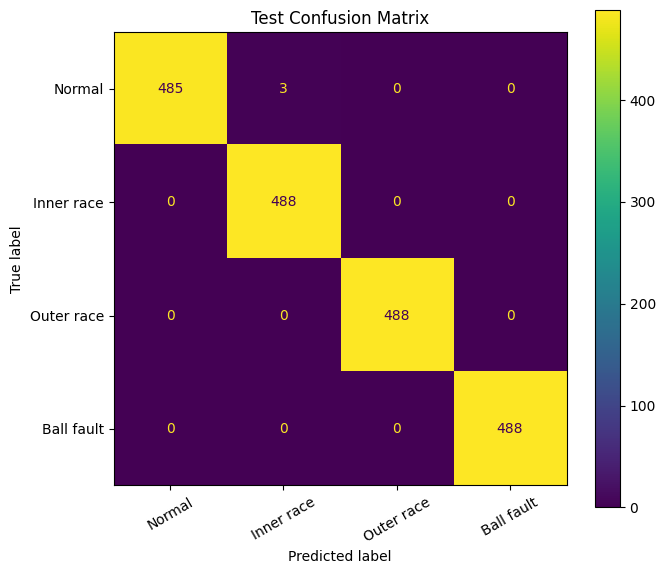

In [ ]:

# Ô 15 - Test model tốt nhất

best_variant_name = best_row["variant"]

best_variant = next(
    variant
    for variant in STFT_VARIANTS
    if variant["name"] == best_variant_name
)

test_records = collect_records(
    "test",
    best_variant_name,
    MAX_TEST_SAMPLES
)

print(
    "Test samples:",
    len(test_records)
)

print(
    "Class counts:",
    class_counts(test_records)
)

test_loader = make_loader(
    records=test_records,
    image_size=best_variant["image_size"],
    shuffle=False,
    seed=RANDOM_SEED,
)

best_model = Bearing2DCNN(
    num_classes=len(CLASS_NAMES)
).to(DEVICE)

saved_state = torch.load(
    RESULT_ROOT
    / best_variant_name
    / "best_model.pt",
    map_location=DEVICE
)

best_model.load_state_dict(
    saved_state
)

criterion = nn.CrossEntropyLoss()

test_result = evaluate_loader(
    model=best_model,
    loader=test_loader,
    criterion=criterion,
    description="Test",
    show_progress=True,
    measure_inference=True,
)

print("\nTEST RESULT")

print(
    f"Accuracy         = "
    f"{test_result['accuracy']*100:.4f}%"
)

print(
    f"Macro Precision  = "
    f"{test_result['precision_macro']*100:.4f}%"
)

print(
    f"Macro Recall     = "
    f"{test_result['recall_macro']*100:.4f}%"
)

print(
    f"Macro F1         = "
    f"{test_result['f1_macro']*100:.4f}%"
)

print(
    f"Inference/sample = "
    f"{test_result['inference_ms_per_sample']:.4f} ms"
)

print("\nMetrics từng lớp:")

display(
    test_result["per_class"]
)

print("\nConfusion matrix:")

print(
    test_result["confusion_matrix"]
)

best_dir = (
    RESULT_ROOT
    / best_variant_name
)

test_result[
    "per_class"
].to_csv(
    best_dir
    / "test_per_class_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

np.savetxt(
    best_dir
    / "test_confusion_matrix.csv",
    test_result["confusion_matrix"],
    delimiter=",",
    fmt="%d"
)

save_confusion_matrix_plot(
    test_result["confusion_matrix"],
    best_dir
    / "test_confusion_matrix.png",
    title="Test Confusion Matrix",
)

test_metrics = {
    "variant":
        best_variant_name,

    "nw":
        int(best_variant["nw"]),

    "h":
        int(best_variant["h"]),

    "image_size":
        int(best_variant["image_size"]),

    "batch_size":
        int(BATCH_SIZE),

    "accuracy":
        test_result["accuracy"],

    "precision_macro":
        test_result["precision_macro"],

    "recall_macro":
        test_result["recall_macro"],

    "f1_macro":
        test_result["f1_macro"],

    "inference_ms_per_sample":
        test_result[
            "inference_ms_per_sample"
        ],
}

with open(
    best_dir
    / "test_metrics.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        test_metrics,
        file,
        ensure_ascii=False,
        indent=2
    )


In [ ]:

# Ô 16 - Xem xác suất Softmax của một mẫu Test

sample_dataset = STFTDataset(
    records=test_records,
    image_size=best_variant[
        "image_size"
    ]
)

x, y = sample_dataset[]

x = (
    x.unsqueeze(0)
    .to(DEVICE)
)

best_model.eval()

with torch.no_grad():

    logits = best_model(x)

    probabilities = torch.softmax(
        logits,
        dim=1
    )

predicted_label = int(
    probabilities.argmax(
        dim=1
    ).item()
)

true_label = int(
    y.item()
)

print(
    "File:",
    test_records[0]["path"]
)

print(
    "Nhãn thật:",
    CLASS_NAMES[
        true_label
    ]
)

print(
    "Logits:",
    logits.cpu()
    .numpy()[0]
)

print("\nXác suất:")

for class_index, class_name in enumerate(
    CLASS_NAMES
):

    print(
        f"{class_name:12s}: "
        f"{probabilities[0, class_index].item()*100:.2f}%"
    )

print(
    "\nDự đoán:",
    CLASS_NAMES[
        predicted_label
    ]
)


NameError: name 'test_records' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



# Tóm tắt

Bản này giữ nguyên quy trình của notebook trước nhưng thay phần tính toán thủ công bằng các hàm PyTorch tối ưu.

Trong mỗi batch:

\[
\text{Input}
\rightarrow
\text{Forward}
\rightarrow
\text{CrossEntropyLoss}
\rightarrow
\text{Backward}
\rightarrow
\text{Adam Update}
\]

Dòng lệnh cốt lõi:

```python
optimizer.zero_grad()
logits = model(x)
loss = criterion(logits, y)
loss.backward()
optimizer.step()
```

Mỗi cửa sổ có một file `best_model.pt` riêng.

Sau khi train 4 cửa sổ, code so sánh bằng Validation Macro-F1, Accuracy và Loss. Cửa sổ tốt nhất mới được đưa qua Test.
